In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [2]:
transactions = pd.read_csv("../data/processed/clean_investor_transactions.csv")

nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv("../data/processed/clean_scheme_performance.csv")

In [4]:
print("TRANSACTIONS")
print(transactions.columns)

print("\nNAV")
print(nav.columns)

print("\nPERFORMANCE")
print(performance.columns)

TRANSACTIONS
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

NAV
Index(['amfi_code', 'date', 'nav'], dtype='str')

PERFORMANCE
Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')


In [5]:
print(nav.head())

print(performance.head())

print(transactions.head())

   amfi_code        date       nav
0     100016  2022-01-03  520.4608
1     100016  2022-01-04  515.0971
2     100016  2022-01-05  521.7239
3     100016  2022-01-06  515.7880
4     100016  2022-01-07  515.1639
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct  

In [6]:
# loading the nav dataset again and using .head() to see its output
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [7]:
# converting date column to datetime
nav['date'] = pd.to_datetime(nav['date'])

nav = nav.sort_values(
    ['amfi_code','date']
)

In [8]:
# calculating daily returns
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
# Calculating Var and CVaR
var_cvar = []

for code, group in nav.groupby('amfi_code'):

    returns = group['daily_return'].dropna()

    if len(returns) > 30:

        var95 = np.percentile(
            returns,
            5
        )

        cvar95 = returns[
            returns <= var95
        ].mean()

        var_cvar.append([
            code,
            var95,
            cvar95
        ])

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [10]:
# Merging Scheme Names
performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

var_cvar_df = (
    var_cvar_df.merge(
        performance[
            ['amfi_code','scheme_name']
        ],
        on='amfi_code',
        how='left'
    )
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [11]:
# Finding Most Risky Funds
var_cvar_df.sort_values(
    'VaR_95'
).head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth


In [12]:
# Exporting Deliverables
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Done")

Done


In [13]:
var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
0,100016,-0.014364,-0.018060,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.003793,-0.004994,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.013282,-0.017439,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth


In [15]:
var_cvar_df.sort_values('VaR_95').head(10)

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth
39,149324,-0.023483,-0.031036,DSP Small Cap Fund - Regular - Growth
7,102886,-0.019220,-0.023251,UTI Mid Cap Fund - Regular - Growth
2,100033,-0.019034,-0.023456,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
25,120505,-0.018892,-0.024342,ICICI Pru Midcap Fund - Regular - Growth
16,119094,-0.018480,-0.024260,Axis Midcap Fund - Regular - Growth


In [16]:
# Task 2 : Rolling 90 day sharpe ratio
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [17]:
# Selecting 5 funds
top5 = performance[
    ['amfi_code','scheme_name']
].head(5)

top5

,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
3,119599,SBI Small Cap Fund - Direct Plan - Growth
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth


In [18]:
# Calculating Rolling Sharpe
rolling_results = []

for code in top5['amfi_code']:

    fund = nav[
        nav['amfi_code'] == code
    ].copy()

    fund = fund.sort_values('date')

    fund['rolling_sharpe'] = (
        fund['daily_return']
        .rolling(90)
        .mean()
        /
        fund['daily_return']
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    fund['amfi_code'] = code

    rolling_results.append(fund)

rolling_df = pd.concat(
    rolling_results
)

rolling_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
21850,119551,2022-01-03,54.3856,NaN,NaN
21851,119551,2022-01-04,54.3474,-0.000702,NaN
21852,119551,2022-01-05,54.6869,0.006247,NaN
21853,119551,2022-01-06,55.4550,0.014045,NaN
21854,119551,2022-01-07,55.3692,-0.001547,NaN


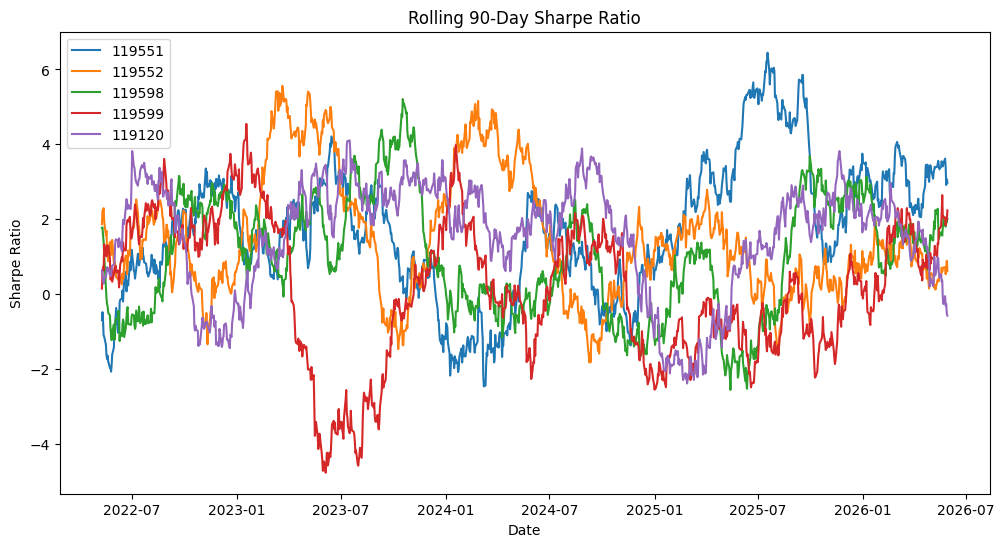

In [19]:
# Creating Chart
plt.figure(figsize=(12,6))

for code in top5['amfi_code']:

    temp = rolling_df[
        rolling_df['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(code)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")

plt.legend()

plt.show()

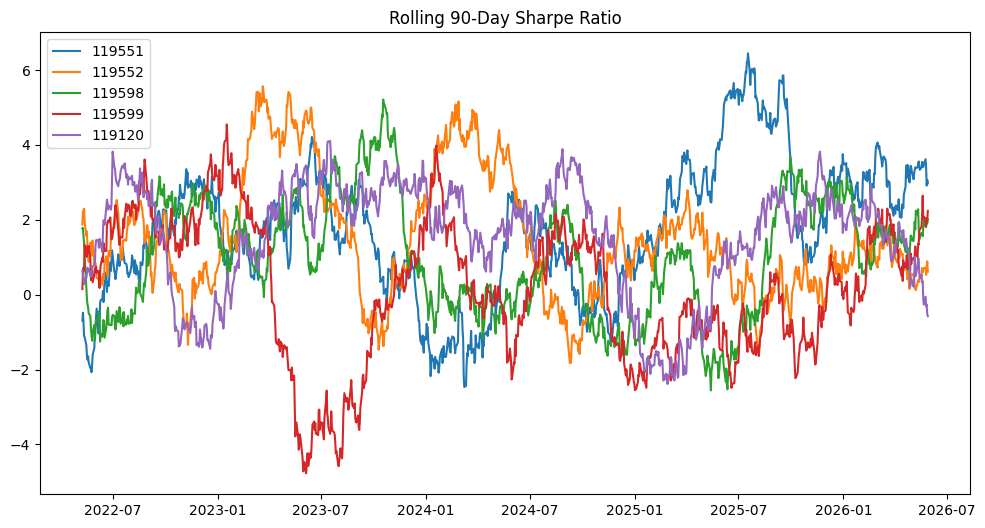

In [20]:
# Saving Deliverable
plt.figure(figsize=(12,6))

for code in top5['amfi_code']:

    temp = rolling_df[
        rolling_df['amfi_code'] == code
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(code)
    )

plt.title("Rolling 90-Day Sharpe Ratio")

plt.legend()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    bbox_inches='tight'
)

plt.show()

In [21]:
# Performing Investor Cohort Analysis
# Create a copy of data
cohort = transactions.copy()

cohort.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [22]:
# COnverting Transaction Date
cohort['transaction_date'] = pd.to_datetime(
    cohort['transaction_date']
)

In [23]:
# Finding First Transaction Year
first_txn = (
    cohort.groupby('investor_id')
          ['transaction_date']
          .min()
          .reset_index()
)

first_txn['cohort_year'] = (
    first_txn['transaction_date']
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [24]:
# Merging Cohort Year
cohort = cohort.merge(
    first_txn[
        ['investor_id','cohort_year']
    ],
    on='investor_id',
    how='left'
)

cohort.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [25]:
# Cohort Summary
cohort_summary = (
    cohort.groupby('cohort_year')
          .agg(
              investors=('investor_id','nunique'),
              total_invested=('amount_inr','sum'),
              avg_investment=('amount_inr','mean')
          )
          .reset_index()
)

cohort_summary

,cohort_year,investors,total_invested,avg_investment
0,2024,4803,3491125187,107422.541832
1,2025,197,30455243,109158.577061


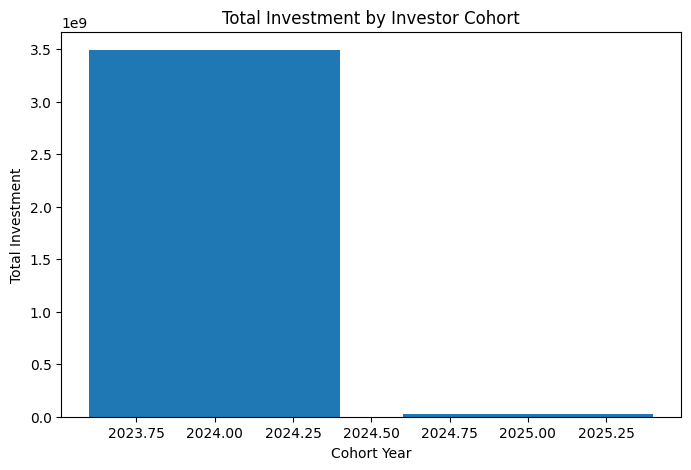

In [26]:
# Visualizing
plt.figure(figsize=(8,5))

plt.bar(
    cohort_summary['cohort_year'],
    cohort_summary['total_invested']
)

plt.title(
    "Total Investment by Investor Cohort"
)

plt.xlabel("Cohort Year")
plt.ylabel("Total Investment")

plt.show()

In [27]:
# Saving Deliverable
cohort_summary.to_csv(
    "../reports/cohort_analysis.csv",
    index=False
)

print("Saved")

Saved


In [28]:
# Finding TOP Fund Preference per cohort
top_fund = (
    cohort.groupby(
        ['cohort_year','amfi_code']
    )
    .size()
    .reset_index(name='count')
)

top_fund = (
    top_fund.sort_values(
        ['cohort_year','count'],
        ascending=[True,False]
    )
    .groupby('cohort_year')
    .head(1)
)

top_fund

,cohort_year,amfi_code,count
35,2024,148568,874
62,2025,119599,12


In [29]:
top_fund.to_csv(
    "../reports/top_fund_preference.csv",
    index=False
)

In [30]:
# Task 4 : SIP Continuity Analysis
# Creating SIP only dataset
sip = transactions[
    transactions['transaction_type']
    == 'SIP'
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [31]:
# Converting date
sip['transaction_date'] = pd.to_datetime(
    sip['transaction_date']
)

sip = sip.sort_values(
    ['investor_id','transaction_date']
)

In [32]:
# Calculating Gap between SIP
sip['previous_date'] = (
    sip.groupby('investor_id')
       ['transaction_date']
       .shift(1)
)

sip['gap_days'] = (
    sip['transaction_date']
    -
    sip['previous_date']
).dt.days

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,previous_date,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,NaT,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024-11-04,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,NaT,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024-03-29,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024-09-21,238.0


In [33]:
# Investor SIP Summary
sip_summary = (
    sip.groupby('investor_id')
       .agg(
           sip_count=('transaction_date','count'),
           avg_gap_days=('gap_days','mean')
       )
       .reset_index()
)

sip_summary.head()

,investor_id,sip_count,avg_gap_days
0,INV000001,2,76.0
1,INV000002,3,207.0
2,INV000003,2,238.0
3,INV000004,6,85.4
4,INV000005,3,14.0


In [34]:
# Keep investor with 6+ SIPs
sip_summary = sip_summary[
    sip_summary['sip_count'] >= 6
]

sip_summary.head()

,investor_id,sip_count,avg_gap_days
3,INV000004,6,85.400000
7,INV000008,6,70.400000
9,INV000010,6,64.800000
10,INV000011,7,40.166667
11,INV000012,8,57.000000


In [35]:
# Flag At-Risk Investors
# GAP >  days = At Risk
sip_summary['status'] = np.where(
    sip_summary['avg_gap_days'] > 35,
    'At Risk',
    'Regular'
)

sip_summary.head()

,investor_id,sip_count,avg_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [36]:
# Investors COunts
sip_summary['status'].value_counts()

status
At Risk    1332
Regular      30
Name: count, dtype: int64

In [37]:
# Exporting Deliverable
sip_summary.to_csv(
    "../reports/sip_continuity_analysis.csv",
    index=False
)

print("Saved")

Saved


In [38]:
# Fund Recommender System

# Check risk grades available
performance['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

In [39]:
performance[['risk_grade','sharpe_ratio']].head()

,risk_grade,sharpe_ratio
0,Moderate,0.88
1,Moderate,0.81
2,Very High,0.94
3,Very High,0.93
4,Low,1.52


In [40]:
# Task 5 : Fund Recommender System
# Get top funds by Sharpe Ratio
recommendations = (
    performance.sort_values(
        'sharpe_ratio',
        ascending=False
    )
)

recommendations[
    ['scheme_name',
     'risk_grade',
     'sharpe_ratio',
     'return_3yr_pct']
].head()

,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,Low,1.84,7.37
4,SBI Magnum Gilt Fund - Regular Plan - Growth,Low,1.52,6.07


In [41]:
# Creating Recommendations for Each Risk level
low_risk = (
    performance[
        performance['risk_grade'] == 'Low'
    ]
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(3)
)

moderate_risk = (
    performance[
        performance['risk_grade'] == 'Moderate'
    ]
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(3)
)

high_risk = (
    performance[
        performance['risk_grade'].isin(
            ['High','Very High']
        )
    ]
    .sort_values(
        'sharpe_ratio',
        ascending=False
    )
    .head(3)
)

In [42]:
# View Recommendations
print("LOW RISK")
display(
    low_risk[
        ['scheme_name',
         'risk_grade',
         'sharpe_ratio']
    ]
)

print("MODERATE RISK")
display(
    moderate_risk[
        ['scheme_name',
         'risk_grade',
         'sharpe_ratio']
    ]
)

print("HIGH RISK")
display(
    high_risk[
        ['scheme_name',
         'risk_grade',
         'sharpe_ratio']
    ]
)

LOW RISK


,scheme_name,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14


MODERATE RISK


,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


HIGH RISK


,scheme_name,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94


In [43]:
# Creating Final Recommendation Table
low_risk['investor_type'] = 'Low Risk'
moderate_risk['investor_type'] = 'Moderate Risk'
high_risk['investor_type'] = 'High Risk'

recommendation_table = pd.concat([
    low_risk,
    moderate_risk,
    high_risk
])

recommendation_table[
    ['investor_type',
     'scheme_name',
     'risk_grade',
     'sharpe_ratio',
     'return_3yr_pct']
]

,investor_type,scheme_name,risk_grade,sharpe_ratio,return_3yr_pct
14,Low Risk,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68,7.68
23,Low Risk,Kotak Liquid Fund - Regular - Growth,Low,6.18,6.18
30,Low Risk,ABSL Liquid Fund - Regular - Growth,Low,5.14,5.14
5,Moderate Risk,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06,14.84
34,Moderate Risk,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06,14.81
11,Moderate Risk,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03,14.41
21,High Risk,Kotak Emerging Equity Fund - Regular - Growth,High,0.96,18.23
12,High Risk,ICICI Pru Midcap Fund - Regular - Growth,High,0.95,18.08
2,High Risk,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94,23.39


In [44]:
# Exporting the Deliverable
recommendation_table.to_csv(
    "../reports/recommendation_table.csv",
    index=False
)

print("Saved")

Saved


In [45]:
# Sector HHI Concentration Analysis
import pandas as pd

performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [46]:
# Calculate the FUnd weights
total_aum = performance['aum_crore'].sum()

performance['weight'] = (
    performance['aum_crore']
    / total_aum
)

performance[['scheme_name','aum_crore','weight']].head()

,scheme_name,aum_crore,weight
0,SBI Bluechip Fund - Regular Plan - Growth,14288,0.013690
1,SBI Bluechip Fund - Direct Plan - Growth,1231,0.001179
2,SBI Small Cap Fund - Regular Plan - Growth,19259,0.018453
3,SBI Small Cap Fund - Direct Plan - Growth,36061,0.034552
4,SBI Magnum Gilt Fund - Regular Plan - Growth,24101,0.023093


In [47]:
# Calculating HHI
hhi = (
    performance['weight'] ** 2
).sum()

print("HHI =", round(hhi,4))

HHI = 0.0318


### HHI Interpretation

HHI < 0.15 → Diversified Market

0.15–0.25 → Moderately Concentrated

>0.25 → Highly Concentrated

The calculated HHI suggests the concentration level of the mutual fund universe based on AUM distribution.

In [48]:
# Saving the result
hhi_df = pd.DataFrame({
    'Metric':['HHI'],
    'Value':[hhi]
})

hhi_df.to_csv(
    "../reports/hhi_analysis.csv",
    index=False
)

print("Saved")

Saved
